Todo: do a full end to end reconstruction of EIT with Tikhonov regularization and save the image. Then change the noise level

In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

Import all the plumbing for the reverse SDE:
the function $sde(x,t)$ evaluates the SDE

In [2]:
include("model/sde.jl")
sde(randn(64,64),1)

64×64 Matrix{Float32}:
  0.558846  -1.88774    -1.11254   …   0.906543    0.676857   0.0518003
  1.20543    0.896978    1.87965      -0.578744   -0.64925    0.176252
  0.599189   1.1446     -0.216754      1.09015     0.14662   -0.168036
 -0.226853  -0.793325    0.456615     -0.52417    -0.43421   -1.4401
 -0.822292   1.37252    -1.06835      -1.00568     0.882238  -0.419007
 -0.97189    0.765803    1.0185    …  -0.891849    0.894678  -0.0112416
  0.87319   -0.956119    0.531305      1.30097     0.529163  -1.47016
  1.88535    0.850928    0.376158     -1.08927    -0.431024   0.920822
 -0.433246   0.423685   -1.62517       0.0655963  -0.95878   -0.0966559
  1.11461    0.571121   -0.63239      -0.949403   -1.789     -1.90788
  ⋮                                ⋱                         
  0.375769   0.473509   -0.213489  …   1.44391    -1.27691    0.60503
 -0.993346   1.15483    -0.137322     -0.208285   -1.07082    0.460135
  0.883098   0.756384   -0.303127     -2.13883    -0.676672   1.6

Just choose the parameters here: 
The current problem is the scale might vary widely based on the chosen grid. Don't know yet how to normalize it.

In [30]:
ρ_obj = 0.0 
ρ_reg = 1e-1 # Regularization strength in prox of regularizer

σf = 0.0e-2 # how much noise is added to f
σg = 0.0e-2 # How much noise is added to g

0.0

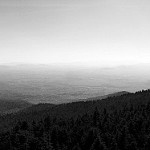

In [31]:
img = load("1096.jpg")

In [32]:
itp = interpolate_array_2D(Float64.(img))

#interpolate_array_2D##0 (generic function with 1 method)

In [33]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,3,∂Ω)
cond_vec = project_function_to_fem(fe, itp)
cond_vec .= min.(max.(cond_vec,1e-6),1.0)

16129-element Vector{Float64}:
 0.6620719480307282
 0.6844350473112841
 0.6927977157805241
 0.670285221753101
 0.675713612074557
 0.6894434399964393
 0.6841917536040899
 0.6672001101490131
 0.6806489158672027
 0.6971524452344506
 ⋮
 0.031167250350174543
 0.015510000235997821
 0.014520427059962142
 0.007829287198868317
 0.008838059259167145
 0.008600073232173749
 0.014341377282337257
 0.012685658965159607
 0.01946419980123187

In [34]:
minimum(cond_vec)

1.0e-6

In [35]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i] = assemble_rhs_func(fe, itp)
end

In [36]:
K = assemble_L(fe, cond_vec)
K_fac = cholesky(K)
mode_dict = Dict{Int64,FerriteEITMode}()
mode_dict_no_noise = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 2:256
        mode_dict[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true, σ_f = σf, σ_g= σg)
        mode_dict_no_noise[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true)
    end
end

  2.586141 seconds (88.57 k allocations: 826.172 MiB, 42.39% gc time, 3.53% compilation time)


In [37]:
Statistics.std(mode_dict[1].g)

1.8993588489722277

In [38]:
#σ_vec = randn(fe.n) #initialize problem with random vector
#@. σ_vec = min(max(σ_vec*0.5 +0.5, 1e-6),1.0)
using Distributions
σ_vec = rand(Uniform(1e-6, 1.0), fe.n)
sol = FerriteSolverState(fe, σ_vec)
prblm = FerriteProblem(fe, mode_dict, sol)

FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.855121263383

In [39]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [40]:
#R, ∇R, prox_reg = create_tikhonov(fe.K,β = 1.0,ρ = ρ_reg)

In [41]:
R, ∇R, prox_reg = create_totalvariation(fe, ρ = ρ_reg)

(ModularEIT.var"#97#98"{FerriteFESpace{RefQuadrilateral}, Float64}(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.472379

In [42]:
f,∂f = create_f∂f(prblm, 255; gn=true)
prox_obj = create_prox_linesearch(f, ∂f, ρ_obj)

#create_prox_linesearch##0 (generic function with 1 method)

In [43]:
σ_05 = 0.5*ones(fe.n)
σ₁ ,err1 = prox_obj(σ_05)
sum(abs2,σ₁- σ_05)

245.16390089475786

In [44]:
using Printf
function admm(prox_f, prox_g, x0; iters=10, print_err=false)
    fmt(x) = @sprintf("%.3e", x) 
    x = copy(x0)
    z = copy(x0)
    u = zero(x0)
    err_x = 0
    err_z = 0
    for k in 1:iters
        x, err_x, p_x = prox_f(z .- u)
        z, err_z, p_z = prox_g(x .+ u)
        u = u .+ x .- z
        if print_err
            println("iter $k: objective: $err_x $(fmt(p_x)) || regularizer: $(fmt(err_z)) $(fmt(p_z))")
        end
    end
    return x, z, u
end

admm (generic function with 1 method)

In [45]:
σ_reg, _ = prox_reg(σ_vec)

([0.7498735370379542, 0.8654724035011101, 0.547093860911637, 0.1116470339310684, 0.3646571013651004, 0.4672883237338969, 0.4373122100079024, 0.31044999991302796, 0.4047368111628945, 0.38825162893088166  …  0.6250340062047968, 0.4681705103698456, 0.5806989965775723, 0.6307610998497325, 0.589204040353403, 0.7421616001022763, 0.30863977078921223, 0.15632612276657498, 0.6639385483995314, 0.4904439487415741], 24.12559452389737, 21.863912330272395)

In [46]:
f_new = f(0.5*ones(fe.n))

0.10588785918037423

In [47]:
f_old = f(0.5*ones(fe.n))

0.10588785918037423

In [48]:
σ₁,err1 = prox_obj(σ_reg)

([0.723829096200093, 0.8358351905704824, 0.5302703780813107, -0.07525243755130603, 0.3252673494611192, 0.449943314728484, 0.3850370253234273, 0.26991308557323007, 0.36110802158648103, 0.4237276890932473  …  0.023640770086186036, 0.23591281901416955, -0.34506104429839224, 0.1244511504002318, 0.4659273161613824, 0.49306826496566525, 0.4186317275620774, -0.5174000320693589, 0.33758848548429515, -0.19930160769308197], 0.09045186218992547, 0.0)

In [49]:
σᵢ, erri = σ₁,err1

([0.723829096200093, 0.8358351905704824, 0.5302703780813107, -0.07525243755130603, 0.3252673494611192, 0.449943314728484, 0.3850370253234273, 0.26991308557323007, 0.36110802158648103, 0.4237276890932473  …  0.023640770086186036, 0.23591281901416955, -0.34506104429839224, 0.1244511504002318, 0.4659273161613824, 0.49306826496566525, 0.4186317275620774, -0.5174000320693589, 0.33758848548429515, -0.19930160769308197], 0.09045186218992547)

In [50]:
x,u,z = admm(prox_obj, prox_reg, σ_vec ; print_err = true)

iter 1: objective: 0.09814400898137819 0.000e+00 || regularizer: 2.504e+01 2.207e+01
iter 2: objective: 0.07318289023037781 0.000e+00 || regularizer: 5.579e+00 1.096e+01
iter 3: objective: 0.07855744459990636 0.000e+00 || regularizer: 1.738e+00 1.868e+00
iter 4: objective: 0.07874358014106733 0.000e+00 || regularizer: 8.782e-01 4.673e-01
iter 5: objective: 0.04020554434133984 0.000e+00 || regularizer: 9.646e-01 5.292e-01
iter 6: objective: 0.05677703191629305 0.000e+00 || regularizer: 6.794e-01 1.541e-01
iter 7: objective: 0.049160602789427674 0.000e+00 || regularizer: 6.333e-01 1.285e-01
iter 8: objective: 0.057793756763251235 0.000e+00 || regularizer: 5.606e-01 3.801e-02
iter 9: objective: 0.03111119519047396 0.000e+00 || regularizer: 6.294e-01 1.982e-01
iter 10: objective: 0.0770356794360375 0.000e+00 || regularizer: 2.001e+00 1.034e+00


([0.639929463088256, 0.3989051877934099, 0.4392950323618188, 0.3543915169534691, 0.5623577758842586, 0.43761764582200485, 0.42137236101448816, 0.5554565386063132, 0.4832001105055379, 0.40287976458223074  …  0.11827526075178739, 0.7525881285642394, 0.2125322389835826, 0.002966344052320692, 0.38182903674909385, 0.2691031464715069, 0.0972763761906212, 0.8648351312260724, -0.15234382642799527, 0.3230432808875983], [0.5827873075708343, 0.4110175617173989, 0.39453600147641005, 0.41058561111256897, 0.4653517345458541, 0.3985888651203357, 0.3962415765551496, 0.4654358930790182, 0.4248790665114625, 0.38038064031382274  …  0.2414488922009763, 0.3350219152370918, 0.1776861525364821, 0.2271235521072648, 0.2375397179406763, 0.23615447266814435, 0.1492492898109558, 0.6089505373573534, -0.05394689189772453, 0.22580339482108186], [0.05272204171823014, -0.01841043063503789, 0.038641353253298205, -0.059743400629989674, 0.08859238139825909, 0.032407849706110214, 0.020118741312710076, 0.08083099166391294,

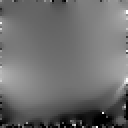

In [51]:
solution = Gray.(max.(min.(reshape(evaluate_at_points(ph, prblm.fe.dh, u),(64,64)),1.0),0.0))

In [52]:
using Printf
fmt(x) = @sprintf("%.3e", x) 
fname = "TotalVariation/$(fmt(ρ_reg))_$(fmt(ρ_obj))_$(fmt(σf))_$(fmt(σg)).png"
save(fname, solution)